In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install -q findspark
!pip install -q xgboost
import findspark
findspark.init()

In [4]:
from pyspark.sql import SparkSession
from pyspark import SparkContext, SparkConf

spark = (
    SparkSession.builder
    .appName("XGBoost_PCA_K25")
    .master("local[*]")
    .config("spark.ui.port", "4050")
    .config("spark.driver.memory", "35g")
    .config("spark.driver.memoryOverhead", "4g")
    .config("spark.sql.shuffle.partitions", "16")
    .config("spark.default.parallelism", "16")
    .config("spark.serializer", "org.apache.spark.serializer.KryoSerializer")
    .config(
        "spark.jars.packages",
        "ml.dmlc:xgboost4j-spark_2.12:1.7.6"
    )
    .getOrCreate()
)


spark


In [ ]:
!pip install -q ngrok


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 39.9 MB/s eta 0:00:00


In [ ]:
!wget -q https://bin.equinox.io/c/bNyj1mQVY4c/ngrok-v3-stable-linux-amd64.tgz
!tar -xzf ngrok-v3-stable-linux-amd64.tgz
!chmod +x ngrok
get_ipython().system_raw('!./ngrok http 4050 &')


In [ ]:
!./ngrok authtoken 372K2OENTZEIyObJBECpiQP0wUR_BgEkQykJerjtRoPQJsoH

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [ ]:
!nohup ./ngrok http 4050 --log=stdout --log-format=logfmt > ngrok.log 2>&1 &


In [5]:
parquet_path_raw = "/content/drive/MyDrive/bigdata/cic_ddos_raw.parquet"
parquet_path_25 = r"/content/drive/MyDrive/bigdata/cic_ddos_pca_25.parquet"
parquet_path_21 = r"/content/drive/MyDrive/bigdata/cic_ddos_pca_21.parquet"
parquet_path_27 = r"/content/drive/MyDrive/bigdata/cic_ddos_rf_27.parquet"

df_feature_raw = spark.read.parquet(parquet_path_raw).cache()
df_feature_25 = spark.read.parquet(parquet_path_25).cache()
df_feature_21 = spark.read.parquet(parquet_path_21).cache()
df_feature_27 = spark.read.parquet(parquet_path_27).cache()

df_feature_25.printSchema(), df_feature_21.printSchema(), df_feature_27.printSchema(), df_feature_raw.printSchema()

root
 |-- pca_k25: vector (nullable = true)
 |-- label: string (nullable = true)

root
 |-- pca_k21: vector (nullable = true)
 |-- label: string (nullable = true)

root
 |-- label: string (nullable = true)
 |-- rf_27: vector (nullable = true)

root
 |-- features: vector (nullable = true)
 |-- label: string (nullable = true)



(None, None, None, None)

In [6]:
from pyspark.ml.feature import StringIndexer
label_indexer = StringIndexer(
    inputCol="label",
    outputCol="label_index",
    handleInvalid="skip"
)
df_indexed_25 = label_indexer.fit(df_feature_25).transform(df_feature_25)
df_indexed_21 = label_indexer.fit(df_feature_21).transform(df_feature_21)
df_indexed_27 = label_indexer.fit(df_feature_27).transform(df_feature_27)
df_indexed_raw = label_indexer.fit(df_feature_raw).transform(df_feature_raw)


In [7]:
from pyspark.sql.functions import lit

def split_train_test(df_indexed):
  fractions = (
      df_indexed
      .select("label")
      .distinct()
      .withColumn("fraction", lit(0.02))
      .rdd.collectAsMap()
  )

  test_df = df_indexed.sampleBy(
      "label",
      fractions,
      seed=42
  )
  return test_df, df_indexed.subtract(test_df)

test_df_25, train_df_25 = split_train_test(df_indexed_25)
test_df_21, train_df_21 = split_train_test(df_indexed_21)
test_df_27, train_df_27 = split_train_test(df_indexed_27)
test_df_raw, train_df_raw = split_train_test(df_indexed_raw)

In [10]:
xgb_model_raw_path = r"/content/drive/MyDrive/bigdata/model/xgboost_cic_ddos_2019_raw"

xgb_model_25_path = r"/content/drive/MyDrive/bigdata/model/xgboost_cic_ddos_2019_pca_k25"

xgb_model_21_path = r"/content/drive/MyDrive/bigdata/model/xgboost_cic_ddos_2019_pca_k21"

xgb_model_27_path = r"/content/drive/MyDrive/bigdata/model/xgboost_cic_ddos_2019_rf_k27"


from xgboost.spark import SparkXGBClassifierModel

xgb_model_raw = SparkXGBClassifierModel.load(xgb_model_raw_path)
xgb_model_25  = SparkXGBClassifierModel.load(xgb_model_25_path)
xgb_model_21  = SparkXGBClassifierModel.load(xgb_model_21_path)
xgb_model_27  = SparkXGBClassifierModel.load(xgb_model_27_path)





In [14]:
df_pred_raw = xgb_model_raw.transform(test_df_raw)
df_pred_k21 = xgb_model_21.transform(test_df_21)
df_pred_k25 = xgb_model_25.transform(test_df_25)
df_pred_k27 = xgb_model_27.transform(test_df_27)


# Acc,F1,Recall,Precision

In [15]:
from sklearn.metrics import classification_report

def evaluate(pdf):
  print(
      classification_report(
          pdf["label_index"],
          pdf["prediction"],
          digits=4
      )
  )

pdf_raw = df_pred_raw.select("label_index", "prediction").toPandas()
pdf_21 = df_pred_k21.select("label_index", "prediction").toPandas()
pdf_25 = df_pred_k25.select("label_index", "prediction").toPandas()
pdf_27 = df_pred_k27.select("label_index", "prediction").toPandas()

print('raw')
evaluate(pdf_raw)

print('K_21')
evaluate(pdf_21)

print('K_25')
evaluate(pdf_25)

print('K_27')
evaluate(pdf_27)

raw
              precision    recall  f1-score   support

         0.0     0.8217    0.8584    0.8397    102744
         1.0     0.8938    0.6134    0.7275    101098
         2.0     0.9890    0.9936    0.9913     90326
         3.0     0.9467    0.9879    0.9669     81979
         4.0     0.4480    0.6868    0.5423     43215
         5.0     0.9318    0.9219    0.9268     31881
         6.0     0.9988    1.0000    0.9994     24211
         7.0     0.6618    0.7006    0.6806      7187
         8.0     1.0000    1.0000    1.0000       555
         9.0     0.8182    1.0000    0.9000         9

    accuracy                         0.8481    483205
   macro avg     0.8510    0.8763    0.8574    483205
weighted avg     0.8698    0.8481    0.8511    483205

K_21
              precision    recall  f1-score   support

         0.0     0.7889    0.8357    0.8116    102639
         1.0     0.8160    0.5555    0.6610    100934
         2.0     0.9880    0.9919    0.9900     90568
         3.0   

# confusion_matrix

In [16]:
from pyspark.ml.feature import StringIndexer

label_indexer_21 = StringIndexer(
    inputCol="label",
    outputCol="label_index",
    handleInvalid="skip"
)

label_indexer_25 = StringIndexer(
    inputCol="label",
    outputCol="label_index",
    handleInvalid="skip"
)

label_model_21 = label_indexer_21.fit(df_feature_21)
label_model_25 = label_indexer_25.fit(df_feature_25)
label_model_27 = label_indexer_21.fit(df_feature_27)
label_model_raw = label_indexer_25.fit(df_feature_raw)


df_indexed_21 = label_model_21.transform(df_feature_21)
df_indexed_25 = label_model_25.transform(df_feature_25)
df_indexed_27 = label_model_21.transform(df_feature_27)
df_indexed_raw = label_model_25.transform(df_feature_raw)


In [17]:
def build_label_map(label_model):
    return spark.createDataFrame(
        [(i, l) for i, l in enumerate(label_model.labels)],
        ["label_index", "label_name"]
    )

label_map_21 = build_label_map(label_model_21)
label_map_25 = build_label_map(label_model_25)
label_map_27 = build_label_map(label_model_21)
label_map_raw = build_label_map(label_model_raw)



In [18]:
from pyspark.sql import functions as F

def confusion_matrix_2d(df, label_col="label_index", pred_col="prediction"):
    return (
        df
        .groupBy(label_col, pred_col)
        .count()
        .groupBy(label_col)
        .pivot(pred_col)
        .sum("count")
        .na.fill(0)
        .orderBy(label_col)
    )


In [19]:
def attach_label_name(cm_df, label_map):
    return (
        cm_df
        .join(label_map, on="label_index", how="left")
        .orderBy("label_index")
    )
cm_k21 = attach_label_name(
    confusion_matrix_2d(df_pred_k21),
    label_map_21
)

cm_k25 = attach_label_name(
    confusion_matrix_2d(df_pred_k25),
    label_map_25
)

cm_k25_v2 = attach_label_name(
    confusion_matrix_2d(df_pred_k27),
    label_map_27
)
cm_raw = attach_label_name(
    confusion_matrix_2d(df_pred_raw),
    label_map_raw
)


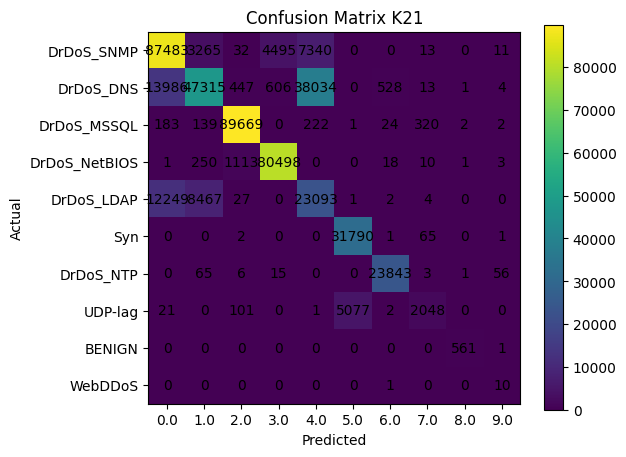

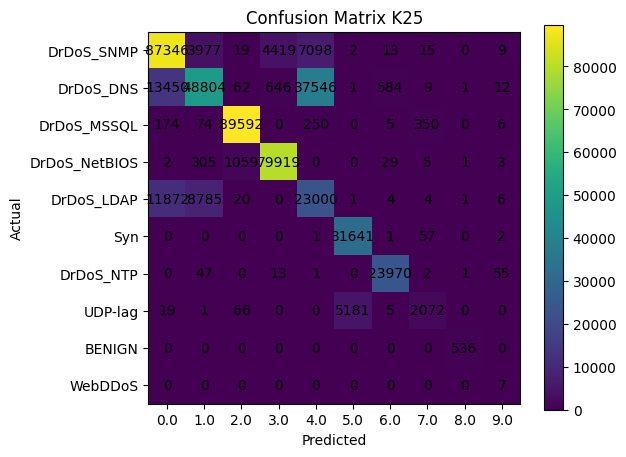

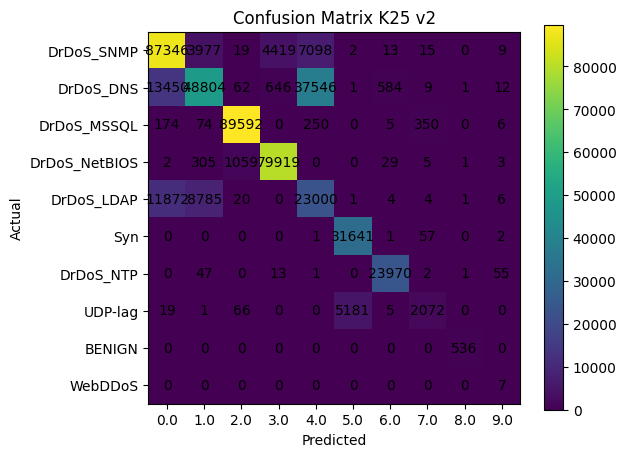

In [ ]:
import matplotlib.pyplot as plt

def plot_confusion_matrix(cm_spark, title):
    pdf = cm_spark.toPandas()

    y_labels = pdf["label_name"]
    pdf = pdf.drop(columns=["label_index", "label_name"])
    mat = pdf.values

    plt.figure(figsize=(6, 5))
    plt.imshow(mat)
    plt.colorbar()
    plt.xticks(range(mat.shape[1]), pdf.columns)
    plt.yticks(range(mat.shape[0]), y_labels)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(title)

    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            plt.text(j, i, int(mat[i, j]), ha="center", va="center")

    plt.show()
plot_confusion_matrix(cm_k21, "Confusion Matrix K21")
plot_confusion_matrix(cm_k25, "Confusion Matrix K25")
plot_confusion_matrix(cm_k25_v2, "Confusion Matrix K25 v2")
